In [4]:
%matplotlib inline
from ultralytics import YOLO
import matplotlib.pyplot as plt

import random
import shutil
from pathlib import Path
from collections import Counter

# Fucntions

In [9]:
def get_samples(img_dir, lbl_dir):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    samples = []
    for img_path in img_dir.iterdir():
        if not img_path.is_file() or img_path.suffix.lower() not in valid_exts:
            continue
        label_path = lbl_dir / f"{img_path.stem}.txt"
        if label_path.is_file():
            txt = label_path.read_text(encoding="utf-8", errors="ignore").strip()
            if txt:
                samples.append((img_path, label_path))

    print(f"Valid labeled samples: {len(samples)}")
    if not samples:
        raise RuntimeError("No labeled samples found")
    return samples

def split_samples(samples, TRAIN_RATIO, VAL_RATIO):
    random.shuffle(samples) #shuffle the samples
    n = len(samples)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)
    train_samples = samples[:n_train]
    val_samples = samples[n_train : n_train + n_val]
    test_samples = samples[n_train + n_val :]
    return train_samples, val_samples, test_samples


def copy_split(split_name, split_samples, dest_path):
    for img_path, lbl_path in split_samples:
        shutil.copy2(img_path, dest_path / split_name / "images" / img_path.name)
        shutil.copy2(lbl_path, dest_path / split_name / "labels" / lbl_path.name)

# Cat Data prep and model develpment

In [11]:
# SOURCE_DATASET: flat YOLO images/ + labels/ under lisa-stop-only.
# YOLO_DATASET: train/val/test copies + dataset.yaml at project root (rebuilt when you rerun the split cell).
SEED = 42
random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve()
cat_source = PROJECT_ROOT / "lisa-stop-only" #labeld data and images 
cat_split = PROJECT_ROOT / "cat_stop_split" #split data into train, val and test
cat_Data_YAML = cat_split / "dataset.yaml" #dataset.yaml file
MODEL_NAME = "yolo11s.pt"
RUNS_DETECT = PROJECT_ROOT / "runs" / "detect"  # Ultralytics train/val logs (absolute)

TRAIN_RATIO = 0.75
VAL_RATIO = 0.10
TEST_RATIO = 1 -TRAIN_RATIO - VAL_RATIO

img_dir = cat_source / "images"
lbl_dir = cat_source / "labels"

if not img_dir.is_dir() or not lbl_dir.is_dir():
    raise FileNotFoundError("Expected lisa-stop-only/images and lisa-stop-only/labels")

samples = get_samples(img_dir, lbl_dir)
train_samples, val_samples, test_samples = split_samples(samples, TRAIN_RATIO, VAL_RATIO)

print(f"train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}")

if cat_split.exists():
    shutil.rmtree(cat_split)

for split in ("train", "val", "test"): #make the directory for the split of the data into train, val and test
    (cat_split / split / "images").mkdir(parents=True, exist_ok=True)
    (cat_split / split / "labels").mkdir(parents=True, exist_ok=True)

for name, part in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    copy_split(name, part, cat_split)

dataset_yaml = f"""path: {cat_split.resolve()}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['stop']
"""

cat_Data_YAML.write_text(dataset_yaml.strip() + "\n", encoding="utf-8")
print("Wrote", cat_Data_YAML.resolve())
for split in ("train", "val", "test"):
    n_img = len(list((cat_split / split / "images").iterdir()))
    n_lbl = len(list((cat_split / split / "labels").glob("*.txt")))
    print(f"{split}: images={n_img}, labels={n_lbl}")

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9
print("Project root:", PROJECT_ROOT)
print("Source:", cat_source)
print("Split output:", cat_split)
print("Model:", MODEL_NAME)
print("Runs dir:", RUNS_DETECT)


Valid labeled samples: 1643
train=1232, val=164, test=247
Wrote /research/bdaqiq/AV-ADAS_detection/cat_stop_split/dataset.yaml
train: images=1232, labels=1232
val: images=164, labels=164
test: images=247, labels=247
Project root: /research/bdaqiq/AV-ADAS_detection
Source: /research/bdaqiq/AV-ADAS_detection/lisa-stop-only
Split output: /research/bdaqiq/AV-ADAS_detection/cat_stop_split
Model: yolo11s.pt


Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1613.8±590.7 MB/s, size: 67.2 KB)
val: Scanning /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/labels... 247 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 247/247 1.6Kit/s 0.2s<0.2s
val: New cache created: /research/bdaqiq/AV-ADAS_detection/cat_stop_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 7.0it/s 2.3s<0.2s
                   all        247        309    0.00763        0.1    0.00463    0.00202
                person        247        309    0.00763        0.1    0.00463    0.00202
Speed: 1.2ms preprocess, 1.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /research/bdaqiq/CSCI611_Basira_Daqiq/runs/detect/val8
Pretrained yolo11s.

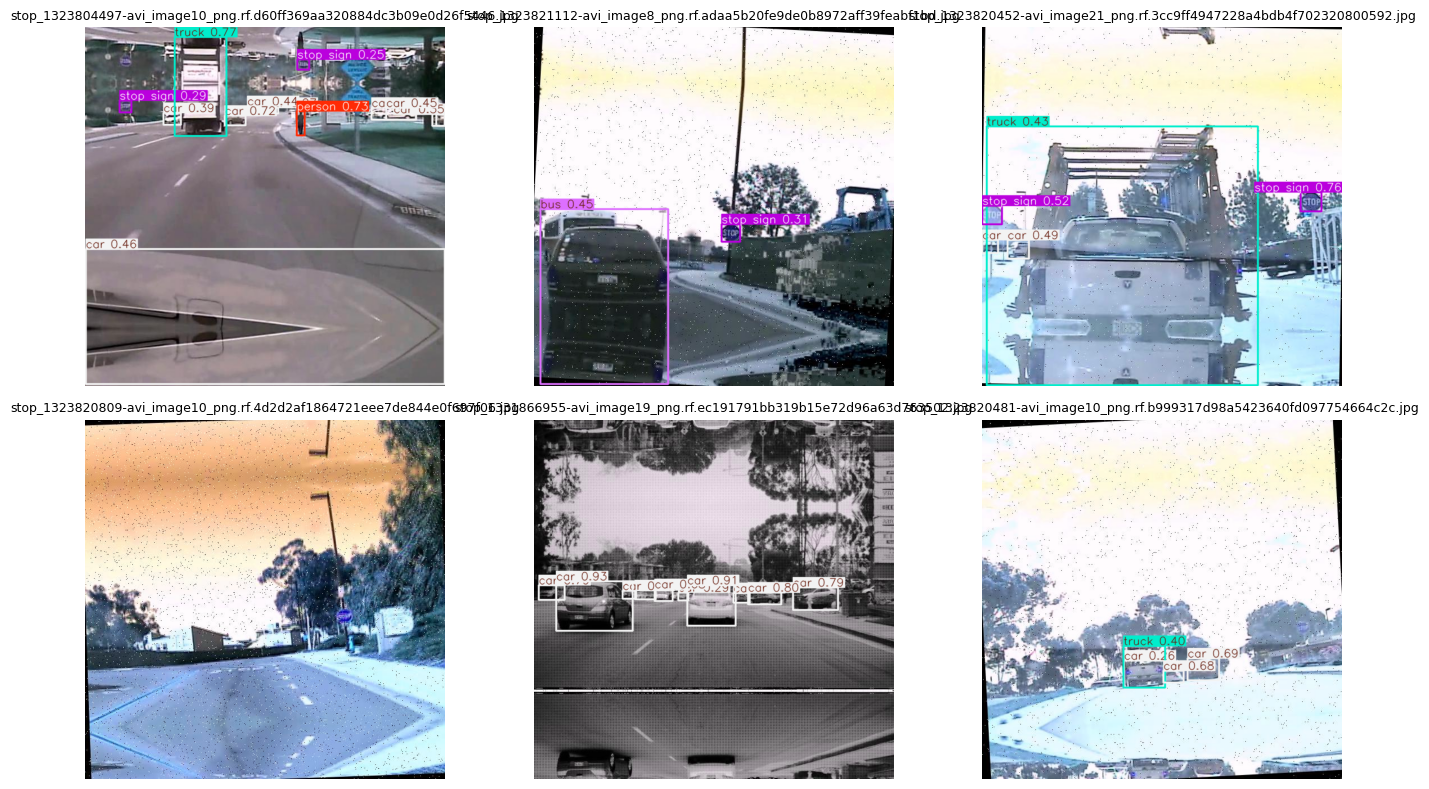

In [12]:
# Evaluate pre-trained YOLO11s on test split before fine-tuning
pretrained_model = YOLO(MODEL_NAME)
pre_val = pretrained_model.val(
    data=str(cat_Data_YAML),
    split="test",
    project=str(RUNS_DETECT),
    name="pretrained_val_test",
)
print(f"Pretrained {MODEL_NAME} -> mAP50={pre_val.box.map50:.4f}, mAP50-95={pre_val.box.map:.4f}")

# Quick visual check on 6 random test images
sample_test = list((cat_split / "test" / "images").glob("*"))
random.shuffle(sample_test)
sample_test = sample_test[:6]

if sample_test:
    preds = pretrained_model([str(p) for p in sample_test])
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(preds):
            ax.imshow(preds[i].plot())
            ax.set_title(sample_test[i].name, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [13]:
# Fine-tune YOLO11s baseline on LISA stop-only split
model_train = YOLO(MODEL_NAME)
results_train = model_train.train(
    data=str(cat_Data_YAML),
    epochs=30,
    imgsz=960,
    batch=8,
    patience=12,
    project=str(RUNS_DETECT),
    name="lisa_stop_yolo11s_baseline",
)

baseline_best = Path(results_train.save_dir) / "weights" / "best.pt"
print("Baseline best:", baseline_best)

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.36 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/research/bdaqiq/AV-ADAS_detection/cat_stop_split/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mos

KeyboardInterrupt: 

In [ ]:
# Fine-tune YOLO11s with stronger augmentations
model_aug = YOLO(MODEL_NAME)
results_aug = model_aug.train(
    data=str(cat_Data_YAML),
    epochs=30,
    imgsz=960,
    batch=8,
    patience=12,
    degrees=12.0,
    scale=0.6,
    shear=4.0,
    translate=0.15,
    fliplr=0.5,
    flipud=0.0,
    mosaic=1.0,
    close_mosaic=8,
    mixup=0.1,
    hsv_h=0.015,
    hsv_s=0.6,
    hsv_v=0.4,
    erasing=0.25,
    project=str(RUNS_DETECT),
    name="lisa_stop_yolo11s_aug",
)

aug_best = Path(results_aug.save_dir) / "weights" / "best.pt"
print("Augmented best:", aug_best)


In [ ]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt

# Models
pretrained = YOLO("yolo11s.pt")
finetuned = YOLO("best_stop_yolo11s_prettygood.pt")  # your trained weights

# Random test images (run config + split cells first)
test_dir = cat_split / "test" / "images"
imgs = list(test_dir.glob("*"))
random.shuffle(imgs)
imgs = imgs[:4]

fig, axes = plt.subplots(len(imgs), 2, figsize=(12, 4 * len(imgs)))
if len(imgs) == 1:
    axes = axes.reshape(1, -1)

for i, img_path in enumerate(imgs):
    p = str(img_path)

    r_pre = pretrained(p)
    axes[i, 0].imshow(r_pre[0].plot())
    axes[i, 0].set_title("Pretrained YOLO11s")
    axes[i, 0].axis("off")

    r_ft = finetuned(p)
    axes[i, 1].imshow(r_ft[0].plot())
    axes[i, 1].set_title("Fine-tuned stop (best_stop_yolo11s.pt)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import shutil

project_root = Path.cwd().resolve()
print("Project root:", project_root)

# 1) First try: use results_train if it exists (from the training cell)
candidates = []
try:
    save_dir = Path(results_train.save_dir).resolve()  # type: ignore[name-defined]
    p = save_dir / "weights" / "best.pt"
    if p.is_file():
        candidates.append(p)
        print("Found via results_train.save_dir:", p)
except Exception as e:
    print("results_train.save_dir not available:", e)

# 2) Fallback: search common places (this repo + your home + /research)
search_roots = [
    project_root,
    project_root.parent,
    Path.home(),
    Path("/research/bdaqiq/AV-ADAS_detection"),
    Path("/research/bdaqiq"),
]

for root in search_roots:
    if root.exists():
        for p in root.rglob("best.pt"):
            # Only consider typical Ultralytics weights path
            if "runs" in p.parts and "weights" in p.parts:
                candidates.append(p)

# De-duplicate and pick newest
candidates = sorted(set(candidates), key=lambda p: p.stat().st_mtime, reverse=True)

if not candidates:
    raise FileNotFoundError("Could not find any runs/**/weights/best.pt. Try searching manually with `find ~ -name best.pt`.")

best_pt = candidates[0]
print("Using best.pt:", best_pt)

# Copy into project root with a clear name
dst = project_root / "best_stop_yolo11s.pt"
shutil.copy2(best_pt, dst)
print("Copied to:", dst)